In [419]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)



# Load & Data Understanding

In [420]:
# train= pd.read_csv('fraudTrain.csv')
# test= pd.read_csv('fraudTest.csv')
# df = pd.concat([train,test],ignore_index=True)

In [421]:
df = pd.read_csv('fraudTrain.csv')
df

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296670,1296670,2020-06-21 12:12:08,30263540414123,fraud_Reichel Inc,entertainment,15.56,Erik,Patterson,M,162 Jessica Row Apt. 072,Hatch,UT,84735,37.7175,-112.4777,258,Geoscientist,1961-11-24,440b587732da4dc1a6395aba5fb41669,1371816728,36.841266,-111.690765,0
1296671,1296671,2020-06-21 12:12:19,6011149206456997,fraud_Abernathy and Sons,food_dining,51.70,Jeffrey,White,M,8617 Holmes Terrace Suite 651,Tuscarora,MD,21790,39.2667,-77.5101,100,"Production assistant, television",1979-12-11,278000d2e0d2277d1de2f890067dcc0a,1371816739,38.906881,-78.246528,0
1296672,1296672,2020-06-21 12:12:32,3514865930894695,fraud_Stiedemann Ltd,food_dining,105.93,Christopher,Castaneda,M,1632 Cohen Drive Suite 639,High Rolls Mountain Park,NM,88325,32.9396,-105.8189,899,Naval architect,1967-08-30,483f52fe67fabef353d552c1e662974c,1371816752,33.619513,-105.130529,0
1296673,1296673,2020-06-21 12:13:36,2720012583106919,"fraud_Reinger, Weissnat and Strosin",food_dining,74.90,Joseph,Murray,M,42933 Ryan Underpass,Manderson,SD,57756,43.3526,-102.5411,1126,Volunteer coordinator,1980-08-18,d667cdcbadaaed3da3f4020e83591c83,1371816816,42.788940,-103.241160,0


In [422]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  str    
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  str    
 4   category               1296675 non-null  str    
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  str    
 7   last                   1296675 non-null  str    
 8   gender                 1296675 non-null  str    
 9   street                 1296675 non-null  str    
 10  city                   1296675 non-null  str    
 11  state                  1296675 non-null  str    
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long                   129667

In [423]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,1296675.0,NaN,NaN,NaN,648337.0,374317.974488,0.0,324168.5,648337.0,972505.5,1296674.0
trans_date_trans_time,1296675,1274791,2019-04-22 16:02:01,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cc_num,1296675.0,NaN,NaN,NaN,417192042079726656.0,1308806447000240384.0,60416207185.0,180042946491150.0,3521417320836166.0,4642255475285942.0,4992346398065154048.0
merchant,1296675,693,fraud_Kilback LLC,4403,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,1296675,14,gas_transport,131659,NaN,NaN,NaN,NaN,NaN,NaN,NaN
amt,1296675.0,NaN,NaN,NaN,70.351035,160.316039,1.0,9.65,47.52,83.14,28948.9
first,1296675,352,Christopher,26669,NaN,NaN,NaN,NaN,NaN,NaN,NaN
last,1296675,481,Smith,28794,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,1296675,2,F,709863,NaN,NaN,NaN,NaN,NaN,NaN,NaN
street,1296675,983,864 Reynolds Plains,3123,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [424]:
df.duplicated().sum()

np.int64(0)

In [425]:
df.isna().sum()

Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

In [426]:
print(df["is_fraud"].value_counts())
print()
print((df["is_fraud"].value_counts(normalize=True) * 100).round(4).astype(str) + " %")

is_fraud
0    1289169
1       7506
Name: count, dtype: int64

is_fraud
0    99.4211 %
1     0.5789 %
Name: proportion, dtype: str


### Feature Description

| Column | Meaning | Type |
|---|---|---|
| `trans_date_trans_time` | Timestamp of the transaction | Datetime |
| `cc_num` | Anonymized credit card number (customer identifier) | Identifier |
| `merchant` | Merchant name where the transaction occurred | Categorical (high cardinality) |
| `category` | Type of purchase (grocery, shopping, entertainment, etc.) | Categorical |
| `amt` | Transaction amount | Numerical |
| `first`, `last` | Cardholder's first/last name | Identifier (not predictive) |
| `gender` | Cardholder's gender (M/F) | Categorical |
| `street`, `city`, `state`, `zip` | Cardholder's home address | Categorical / Identifier |
| `lat`, `long` | Cardholder's home coordinates | Numerical (geo) |
| `city_pop` | Population of the cardholder's city | Numerical |
| `job` | Cardholder's occupation | Categorical (high cardinality) |
| `dob` | Cardholder's date of birth | Date |
| `trans_num` | Unique transaction ID | Identifier |
| `unix_time` | Transaction time as a Unix timestamp | Numerical (redundant with `trans_date_trans_time`) |
| `merch_lat`, `merch_long` | Merchant's coordinates | Numerical (geo) |
| `is_fraud` | **Target**: 1 = fraudulent transaction, 0 = legitimate | Binary target |


# Data Cleaning

In [427]:
df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"])
df["dob"] = pd.to_datetime(df["dob"])

print("Negative or zero amounts:", (df["amt"] <= 0).sum())
print("DOB after transaction date (impossible):", (df["dob"] > df["trans_date_trans_time"]).sum())

print("Transaction date range:", df["trans_date_trans_time"].min(), "to", df["trans_date_trans_time"].max())
print("Age range implied:", ((df['trans_date_trans_time']-df['dob']).dt.days/365.25).min().round(1),
      "to", ((df['trans_date_trans_time']-df['dob']).dt.days/365.25).max().round(1))

Negative or zero amounts: 0
DOB after transaction date (impossible): 0
Transaction date range: 2019-01-01 00:00:18 to 2020-06-21 12:13:37
Age range implied: 13.9 to 95.6


In [428]:
df["merchant"] = df["merchant"].str.replace("fraud_", "", case=False, regex=False).str.strip()
df['merchant'].head()

0            Rippin, Kub and Mann
1       Heller, Gutmann and Zieme
2                  Lind-Buckridge
3    Kutch, Hermiston and Farrell
4                   Keeling-Crist
Name: merchant, dtype: str

# EDA

### Q1 — How rare is fraud, exactly, and what does that mean for modeling?

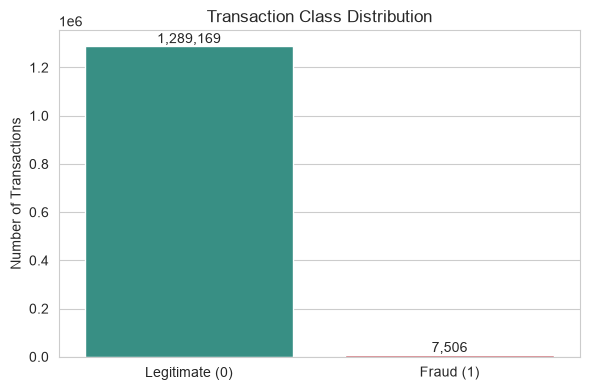

In [429]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x="is_fraud", hue="is_fraud", palette=["#2a9d8f", "#d64550"], legend=False)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Legitimate (0)", "Fraud (1)"])
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
plt.title("Transaction Class Distribution")
plt.ylabel("Number of Transactions")
plt.xlabel("")
plt.tight_layout()
plt.show()


**Insight:** fraud is only ~0.58% of transactions — a model that always predicts "legitimate"
would already be 99.4% accurate. Accuracy is meaningless here; I'll evaluate with
Precision/Recall/F1/PR-AUC instead, and every model needs class-imbalance handling
(`class_weight="balanced"` or `scale_pos_weight`), not plain fitting.

### Q2 — Do fraudulent transactions involve different amounts than legitimate ones?

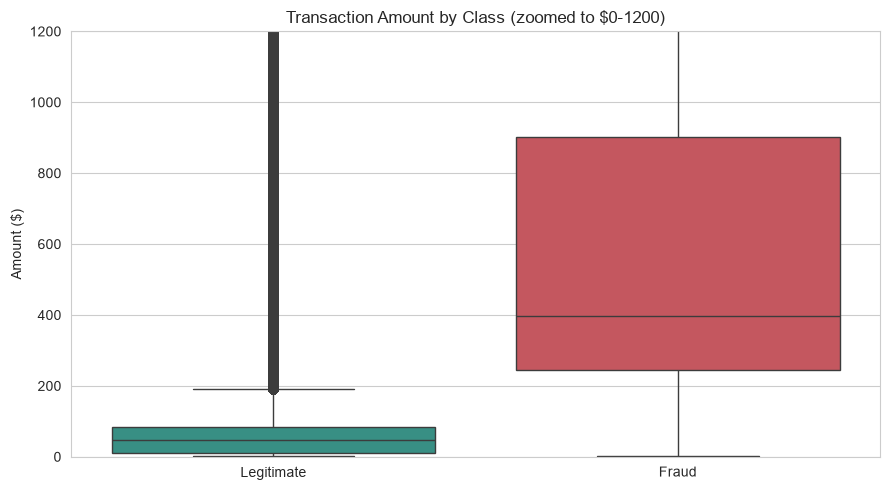

                mean      50%      75%       max
is_fraud                                        
0          67.667110   47.280   82.540  28948.90
1         531.320092  396.505  900.875   1376.04


In [430]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="is_fraud", y="amt", hue="is_fraud", palette=["#2a9d8f", "#d64550"], legend=False)
plt.ylim(0, 1200)
plt.xticks([0, 1], ["Legitimate", "Fraud"])
plt.title("Transaction Amount by Class (zoomed to $0-1200)")
plt.xlabel("")
plt.ylabel("Amount ($)")
plt.tight_layout()
plt.show()

print(df.groupby("is_fraud")["amt"].describe()[["mean","50%","75%","max"]])


**Insight:** fraudulent transactions are dramatically larger — median ~\$396 vs ~\$47 for
legitimate ones, and the mean is over 7x higher. Amount alone is one of the strongest single
signals in this dataset.

### Q3 — Does fraud cluster at particular hours of the day?

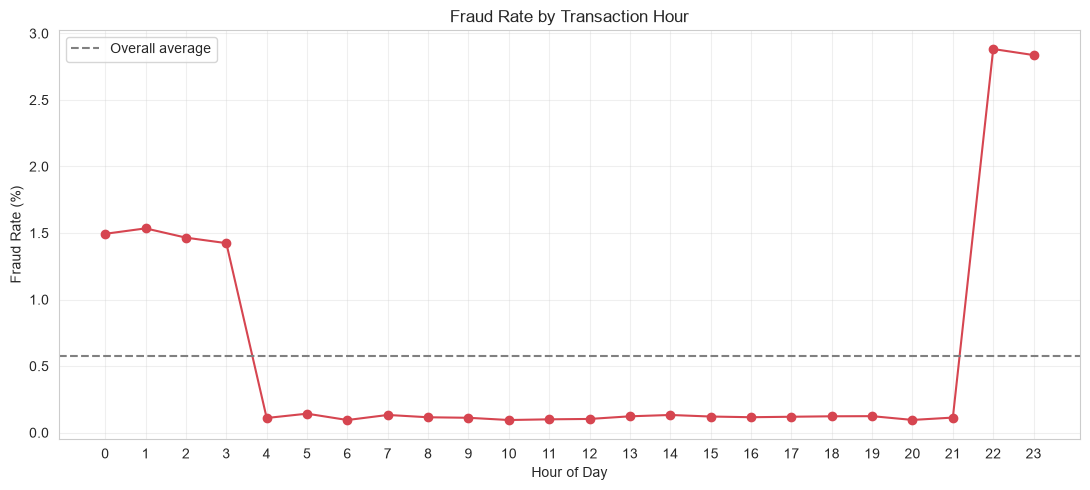

In [431]:
df["trans_hour"] = df["trans_date_trans_time"].dt.hour

hour_fraud_rate = df.groupby("trans_hour")["is_fraud"].mean() * 100

plt.figure(figsize=(11, 5))
plt.plot(hour_fraud_rate.index, hour_fraud_rate.values, marker="o", color="#d64550")
plt.axhline(df["is_fraud"].mean() * 100, color="gray", linestyle="--", label="Overall average")
plt.xticks(range(24))
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate by Transaction Hour")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Insight:** fraud rate is flat around ~0.1% during normal daytime hours, but spikes to
~1.4-1.5% between midnight-3am and ~2.8-2.9% at 22:00-23:00 — roughly **25x** the daytime rate.
The linear correlation between raw hour and fraud is nearly zero (it's a spike pattern, not a
straight-line trend), which is exactly why simply extracting `trans_hour` as a feature — rather
than relying on `unix_time` — matters: a tree-based model can split on this directly, but only
if the feature exists in a form it can use.

### Q4 — Does the purchase category matter?

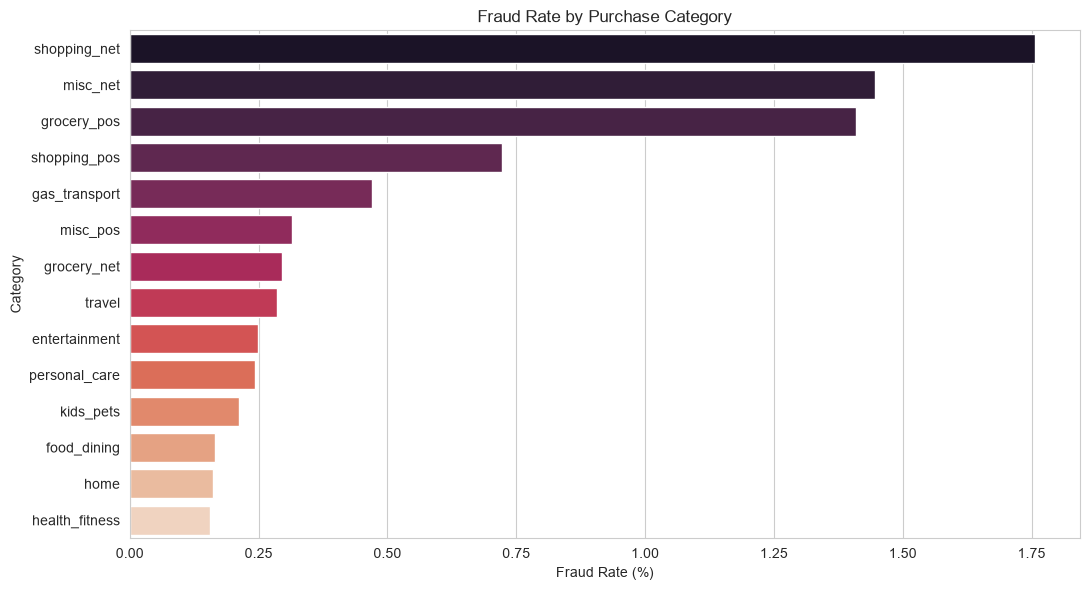

In [432]:
cat_fraud_rate = df.groupby("category")["is_fraud"].mean().mul(100).sort_values(ascending=False)

plt.figure(figsize=(11, 6))
sns.barplot(x=cat_fraud_rate.values, y=cat_fraud_rate.index, hue=cat_fraud_rate.index,
            palette="rocket", legend=False)
plt.xlabel("Fraud Rate (%)")
plt.ylabel("Category")
plt.title("Fraud Rate by Purchase Category")
plt.tight_layout()
plt.show()


**Insight:** `shopping_net`, `misc_net`, and `grocery_pos` have fraud rates 3-10x higher than
categories like `health_fitness` or `home`. Online ("_net") categories skew riskier than
in-person ("_pos") ones for the same type of purchase — worth keeping `category` as a model
feature rather than dropping it.

### Q5 — Is the day of week meaningfully related to fraud?

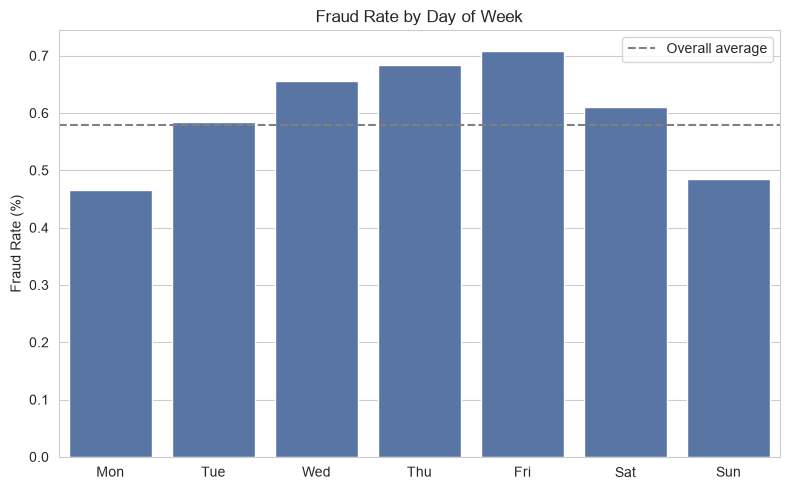

In [433]:
df["trans_dayofweek"] = df["trans_date_trans_time"].dt.dayofweek  # 0=Mon ... 6=Sun

dow_labels = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
dow_fraud_rate = df.groupby("trans_dayofweek")["is_fraud"].mean().mul(100)

plt.figure(figsize=(8, 5))
sns.barplot(x=dow_labels, y=dow_fraud_rate.values, color="#4C72B0")
plt.axhline(df["is_fraud"].mean()*100, color="gray", linestyle="--", label="Overall average")
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate by Day of Week")
plt.legend()
plt.tight_layout()
plt.show()


**Insight:** there's a mild upward drift from Monday (~0.47%) to Friday (~0.71%), dropping
back over the weekend. The effect is real but small compared to the hour-of-day effect — worth
including as a feature, but I wouldn't expect it to rank as a top predictor.

### Q6 — Are the numeric features correlated with fraud and with each other?

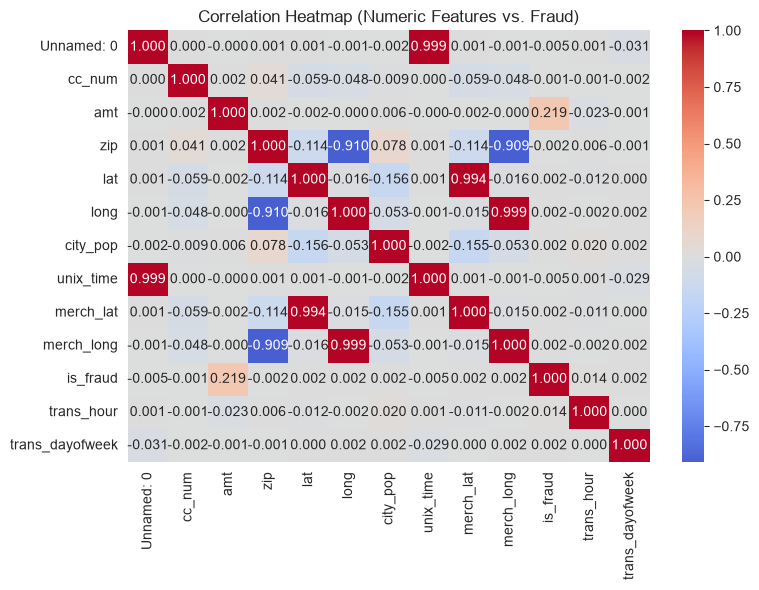

In [434]:
num= df.select_dtypes(include='number').columns

plt.figure(figsize=(8, 6))

sns.heatmap(df[num].corr(), annot=True, fmt=".3f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Numeric Features vs. Fraud)")
plt.tight_layout()
plt.show()


**Insight:** `amt` has the strongest linear correlation with fraud (~0.22) of the numeric
features; `trans_hour`, `trans_dayofweek`, and `city_pop` all look weak here (~0.01-0.02)
**despite** Q3 showing a huge non-linear hour effect — this is the classic trap of judging a
categorical-like/non-monotonic feature by Pearson correlation alone. I'll rely on the grouped
fraud-rate views (Q3, Q4, Q5) rather than this heatmap to decide what to keep — see Feature
Engineering below.

# Feature Engineering

In [435]:
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,trans_hour,trans_dayofweek
0,0,2019-01-01 00:00:18,2703186189652095,"Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,0,1
1,1,2019-01-01 00:00:44,630423337322,"Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,0,1
2,2,2019-01-01 00:00:51,38859492057661,Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,0,1
3,3,2019-01-01 00:01:16,3534093764340240,"Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,0,1
4,4,2019-01-01 00:03:06,375534208663984,Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,0,1


In [ ]:

def haversine(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(
        np.radians,
        [lat1, lon1, lat2, lon2]
    )

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1) * np.cos(lat2)
        * np.sin(dlon / 2) ** 2
    )

    c = 2 * np.arcsin(np.sqrt(a))

    return 6371 * c


def feature_engineering(df):
    df = df.copy()

    # Transaction time features
    df["trans_hour"] = df["trans_date_trans_time"].dt.hour
    df["trans_day"] = df["trans_date_trans_time"].dt.day
    df["trans_month"] = df["trans_date_trans_time"].dt.month
    df["trans_dayofweek"] = df["trans_date_trans_time"].dt.dayofweek

    # Customer age at transaction time
    df["age"] = (
        (df["trans_date_trans_time"] - df["dob"]).dt.days / 365.25
    ).astype(int)

    # Distance between customer and merchant
    df["distance_km"] = haversine(    
        df["lat"],
        df["long"],
        df["merch_lat"],
        df["merch_long"]
    )

    return df
df = feature_engineering(df)
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,trans_hour,trans_dayofweek,trans_day,trans_month,age,distance_km
0,0,2019-01-01 00:00:18,2703186189652095,"Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,0,1,1,1,30,78.597568
1,1,2019-01-01 00:00:44,630423337322,"Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,0,1,1,1,40,30.212176
2,2,2019-01-01 00:00:51,38859492057661,Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,0,1,1,1,56,108.206083
3,3,2019-01-01 00:01:16,3534093764340240,"Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,0,1,1,1,51,95.673231
4,4,2019-01-01 00:03:06,375534208663984,Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,0,1,1,1,32,77.556744


In [437]:
DROP_COLS = [
    "Unnamed: 0",
    "trans_date_trans_time",
    "dob",
    "first",
    "last",
    "street",
    "city",
    "zip",
    "trans_num",
    "unix_time",

    # Features unavailable from user input
    "cc_num",
    "lat",
    "long",
    "city_pop",
    "merch_lat",
    "merch_long"
]


df.drop(columns=DROP_COLS, inplace=True)
df.head()

,merchant,category,amt,gender,state,job,is_fraud,trans_hour,trans_dayofweek,trans_day,trans_month,age,distance_km
0,"Rippin, Kub and Mann",misc_net,4.97,F,NC,"Psychologist, counselling",0,0,1,1,1,30,78.597568
1,"Heller, Gutmann and Zieme",grocery_pos,107.23,F,WA,Special educational needs teacher,0,0,1,1,1,40,30.212176
2,Lind-Buckridge,entertainment,220.11,M,ID,Nature conservation officer,0,0,1,1,1,56,108.206083
3,"Kutch, Hermiston and Farrell",gas_transport,45.00,M,MT,Patent attorney,0,0,1,1,1,51,95.673231
4,Keeling-Crist,misc_pos,41.96,M,VA,Dance movement psychotherapist,0,0,1,1,1,32,77.556744


In [438]:
df.loc[:,['is_fraud','distance_km']].corr()

,is_fraud,distance_km
is_fraud,1.000000,0.000403
distance_km,0.000403,1.000000


**insight** (disance_km) doesn't have good correlation with is_fraud , and it is hard to compute it for the users , so i wil drop it 

In [439]:
df.drop('distance_km',axis=1,inplace=True)

# Split The Data

In [440]:
from sklearn.model_selection import train_test_split

x= df.drop('is_fraud', axis=1)
y = df['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"Train: {X_train.shape}, fraud rate {y_train.mean():.4%}")
print(f"Test:  {X_test.shape}, fraud rate {y_test.mean():.4%}")

Train: (1037340, 11), fraud rate 0.5789%
Test:  (259335, 11), fraud rate 0.5788%


# Data preprocessing

In [441]:
X_train_org = X_train.copy()
X_test_org= X_test.copy()


y_train_org = y_train.copy()
y_test_org= y_test.copy()

## Encoding

In [442]:
cat = df.select_dtypes(include=['str','object']).columns

for col in cat:
    print(col,": ",df[col].unique()," \nCount:  ",df[col].value_counts())

merchant :  <ArrowStringArray>
[         'Rippin, Kub and Mann',     'Heller, Gutmann and Zieme',
                'Lind-Buckridge',  'Kutch, Hermiston and Farrell',
                 'Keeling-Crist',    'Stroman, Hudson and Erdman',
               'Rowe-Vandervort',                'Corwin-Collins',
                    'Herzog Ltd',   'Schoen, Kuphal and Nitzsche',
 ...
  'Kohler, Lindgren and Koelpin',                'Heller-Abshire',
  'Swift, Bradtke and Marquardt',   'Larson, Quitzon and Spencer',
 'Kilback, Nitzsche and Leffler',              'Jakubowski Group',
               'Breitenberg LLC',                   'Collier Inc',
                   'Paucek-Wiza',                 'Kessler Group']
Length: 693, dtype: str  
Count:   merchant
Kilback LLC                       4403
Cormier LLC                       3649
Schumm PLC                        3634
Kuhn LLC                          3510
Boyer PLC                         3493
                                  ... 
Douglas, DuBuque

In [443]:

# Binary encode gender
X_train["gender"] = X_train["gender"].map({"F": 0, "M": 1})
X_test["gender"] = X_test["gender"].map({"F": 0, "M": 1})

onehot_cols = ["category", "state"]
freq_cols = ["merchant", "job"]
numeric_cols = ["amt", "trans_hour",'trans_month',"trans_dayofweek", "age", "gender"]

from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
X_train_ohe = ohe.fit_transform(X_train[onehot_cols])
X_test_ohe = ohe.transform(X_test[onehot_cols])
ohe_cols_out = ohe.get_feature_names_out(onehot_cols)

X_train_ohe = pd.DataFrame(X_train_ohe, columns=ohe_cols_out, index=X_train.index)
X_test_ohe = pd.DataFrame(X_test_ohe, columns=ohe_cols_out, index=X_test.index)

for col in freq_cols:
    freq_map = X_train[col].value_counts(normalize=True)
    X_train[col + "_freq"] = X_train[col].map(freq_map)
    X_test[col + "_freq"] = X_test[col].map(freq_map).fillna(0)  # unseen categories -> 0

X_train_final = pd.concat([X_train[numeric_cols + ["merchant_freq", "job_freq"]], X_train_ohe], axis=1)
X_test_final = pd.concat([X_test[numeric_cols + ["merchant_freq", "job_freq"]], X_test_ohe], axis=1)

print("Final training matrix:", X_train_final.shape)
print("Final test matrix:", X_test_final.shape)
print("Any nulls?", X_train_final.isnull().sum().sum(), X_test_final.isnull().sum().sum())


Final training matrix: (1037340, 73)
Final test matrix: (259335, 73)
Any nulls? 0 0


In [444]:
X_train=X_train_final
X_test=X_test_final

In [445]:
# import category_encoders as ce

# target_encode=['merchant','state','job']
# one_hot_encode=['gender','category']

# encoder_tar= ce.TargetEncoder(cols=['merchant','state','job'])

# X_train[['merchant','state','job']] = encoder_tar.fit_transform(X_train[['merchant','state','job']],y_train)
# X_test[['merchant','state','job']] = encoder_tar.transform(X_test[['merchant','state','job']])

# X_train

In [446]:
# from sklearn.preprocessing import OneHotEncoder
# ohn= OneHotEncoder(sparse_output=False,handle_unknown='ignore')

# X_train_enode= ohn.fit_transform(X_train[one_hot_encode])
# X_test_enode= ohn.transform(X_test[one_hot_encode])

# X_train_enode=pd.DataFrame(X_train_enode,columns=ohn.get_feature_names_out(one_hot_encode),index=X_train.index)
# X_test_enode=pd.DataFrame(X_test_enode,columns=ohn.get_feature_names_out(one_hot_encode),index=X_test.index)



# X_train=pd.concat([X_train.drop(columns=one_hot_encode),X_train_enode],axis=1)
# X_test=pd.concat([X_test.drop(columns=one_hot_encode),X_test_enode],axis=1)

# X_train


# Scaling

In [447]:
from sklearn.preprocessing import RobustScaler
scaler= RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_train_scaled= pd.DataFrame(X_train_scaled,columns=X_test.columns,index=y_train.index)


X_test_scaled=scaler.transform(X_test)
X_test_scaled = pd.DataFrame(X_test_scaled,columns=X_train.columns,index=y_test.index)

X_train_scaled

,amt,trans_hour,trans_month,trans_dayofweek,age,gender,merchant_freq,job_freq,category_entertainment,category_food_dining,category_gas_transport,category_grocery_net,category_grocery_pos,category_health_fitness,category_home,category_kids_pets,category_misc_net,category_misc_pos,category_personal_care,category_shopping_net,category_shopping_pos,category_travel,state_AK,state_AL,state_AR,state_AZ,state_CA,state_CO,state_CT,state_DC,state_DE,state_FL,state_GA,state_HI,state_IA,state_ID,state_IL,state_IN,state_KS,state_KY,state_LA,state_MA,state_MD,state_ME,state_MI,state_MN,state_MO,state_MS,state_MT,state_NC,state_ND,state_NE,state_NH,state_NJ,state_NM,state_NV,state_NY,state_OH,state_OK,state_OR,state_PA,state_RI,state_SC,state_SD,state_TN,state_TX,state_UT,state_VA,state_VT,state_WA,state_WI,state_WV,state_WY
509059,0.057357,-0.916667,0.333333,0.25,-0.60,0.0,-1.650943,1.215195,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
395295,-0.459401,0.416667,0.000000,0.50,0.20,0.0,-0.269811,-0.183786,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
536531,12.449046,0.000000,0.333333,0.75,-0.36,0.0,0.447170,0.003820,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
271001,-0.052044,0.583333,-0.166667,-0.75,0.40,1.0,-0.416981,-0.870119,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
532788,-0.196458,0.000000,0.333333,0.50,-0.88,0.0,-0.250943,1.729202,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125527,-0.378747,0.583333,-0.500000,0.75,-0.40,0.0,-0.216981,1.034805,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
150047,1.034741,-0.750000,-0.500000,0.25,0.04,1.0,0.500000,0.815789,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1151888,0.238147,0.333333,-0.333333,0.50,0.20,0.0,-0.354717,0.498727,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
547306,-0.188692,0.000000,0.333333,0.00,-0.68,1.0,0.315094,0.525891,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1

# Imbalance Analysis 

In [448]:
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()


print("\nNOT Fraud samples:", negative)
print("Fraud samples:", positive)
imbalance_ratio = negative / positive
print("\nImbalance Ratio:", imbalance_ratio)


NOT Fraud samples: 1031335
Fraud samples: 6005

Imbalance Ratio: 171.74604496253122


In [449]:
sub_idx, _ = train_test_split(X_train.index, train_size=150_000, stratify=y_train, random_state=42)
X_sub = X_train.loc[sub_idx]
y_sub = y_train.loc[sub_idx]
scale_pos_weight_sub = (y_sub == 0).sum() / (y_sub == 1).sum()


# Building Model

In [450]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score,average_precision_score
)

results = {}

def evaluate_classifier(name, model, X_te, y_te, y_pred, y_proba=None):
    '''Compute and store the standard classification metrics for one trained model.'''
    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred)
    rec = recall_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred)
    auc = roc_auc_score(y_te, y_proba) if y_proba is not None else np.nan
    pr_auc=average_precision_score(y_te,y_proba)  if y_proba is not None else np.nan

    results[name] = {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1-Score": f1, "ROC-AUC": auc,"PR-AUC":pr_auc}

    print(f"--- {name} ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f'Pr_AUC:    {pr_auc:.4f}')

    if y_proba is not None:
        print(f"ROC-AUC:   {auc:.4f}")
    print()
    return results[name]

In [451]:
# from sklearn.linear_model import LogisticRegression
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.ensemble import RandomForestClassifier
# from xgboost import XGBClassifier
# from lightgbm import LGBMClassifier
# from sklearn.pipeline import  Pipeline
# from sklearn.preprocessing import RobustScaler

# models = {
#     "Logistic Regression": Pipeline([
#         ("scaler", RobustScaler()),
#         ("model", LogisticRegression(
#             max_iter=1000,
#             class_weight="balanced",
#             random_state=42
#         ))
#     ]),
#     "Decision Tree": DecisionTreeClassifier(
#         max_depth=10,
#         class_weight="balanced",
#         random_state=42
#     ),
#     "Random Forest": RandomForestClassifier(
#         class_weight="balanced",
#         random_state=42,
#         n_jobs=-1
#     ),
#     "XGBoost": XGBClassifier(
#         scale_pos_weight=scale_pos_weight_sub,
#         random_state=42,
#         n_jobs=-1
#     ),
#     "LightGBM": LGBMClassifier(
#         scale_pos_weight=scale_pos_weight_sub,
#         random_state=42,
#         n_jobs=-1,
#         verbose=-1  
#     )
# }

# for name, model in models.items():
#     model.fit(X_train,y_train)
#     y_pred = model.predict(X_sub)
#     y_proba = model.predict_proba(X_sub)[:,1]

#     evaluate_classifier(name,model,X_sub,y_sub,y_pred,y_proba)

In [452]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

sub_idx, _ = train_test_split(X_train_final.index, train_size=150_000, stratify=y_train, random_state=42)
X_sub = X_train_final.loc[sub_idx]
y_sub = y_train.loc[sub_idx]
scale_pos_weight_sub = (y_sub == 0).sum() / (y_sub == 1).sum()

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=500, class_weight="balanced", random_state=42))
    ]),
    "Decision Tree": DecisionTreeClassifier(max_depth=10, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=12, class_weight="balanced",
                                             random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(scale_pos_weight=scale_pos_weight_sub,
                              eval_metric="logloss", random_state=42, n_jobs=-1),
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
scoring = {"precision": "precision", "recall": "recall", "f1": "f1",
           "roc_auc": "roc_auc", "pr_auc": "average_precision"}

comparison_results = []
for name, model in models.items():
    cv_res = cross_validate(model, X_sub, y_sub, cv=cv, scoring=scoring, n_jobs=1)
    comparison_results.append({
        "Model": name,
        "Precision": cv_res["test_precision"].mean(),
        "Recall": cv_res["test_recall"].mean(),
        "F1": cv_res["test_f1"].mean(),
        "ROC-AUC": cv_res["test_roc_auc"].mean(),
        "PR-AUC": cv_res["test_pr_auc"].mean(),
    })

comparison_df = pd.DataFrame(comparison_results).sort_values("PR-AUC", ascending=False).reset_index(drop=True)
comparison_df.round(4)


,Model,Precision,Recall,F1,ROC-AUC,PR-AUC
0,XGBoost,0.7056,0.8260,0.7610,0.9920,0.8551
1,Random Forest,0.4143,0.8214,0.5504,0.9830,0.7449
2,Decision Tree,0.1467,0.8940,0.2520,0.9441,0.4020
3,Logistic Regression,0.0315,0.7500,0.0604,0.8976,0.1490


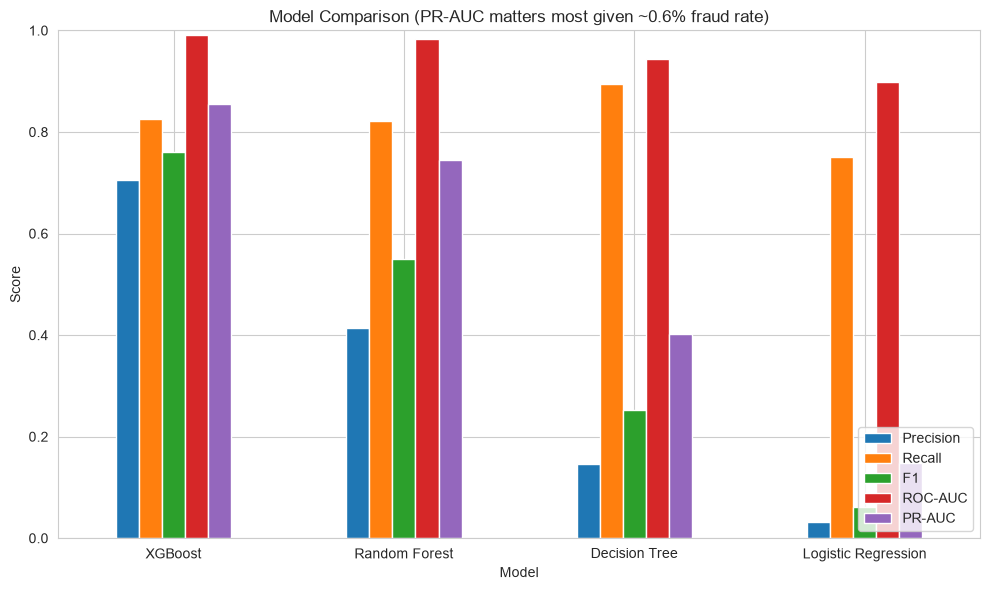

In [453]:
comparison_df.set_index("Model")[["Precision","Recall","F1","ROC-AUC","PR-AUC"]].plot(
    kind="bar", figsize=(10, 6)
)
plt.title("Model Comparison (PR-AUC matters most given ~0.6% fraud rate)")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


# Hyperparameters Tuning for XGboost

In [454]:
# import optuna
# from optuna.integration import XGBoostPruningCallback


# # Objective Function with Pruning
# def objective(trial):
#     params = {
#         "n_estimators": 400,
#         "max_depth": trial.suggest_int("max_depth", 3, 10),
#         "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
#         "subsample": trial.suggest_float("subsample", 0.5, 1.0),
#         "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 1.0),
#         "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
#         "gamma": trial.suggest_float("gamma", 1e-8, 1.0, log=True),
#         "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
#         "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
#         "eval_metric": "logloss",
#         "early_stopping_rounds": 50,
#         "random_state": 42,
#         "n_jobs": -1,
#     }

#     # Prunes trials based on the validation set logloss at each boosting step
#     pruning_callback = XGBoostPruningCallback(trial, "validation_0-logloss")

#     model = XGBClassifier(**params, callbacks=[pruning_callback])

#     # Fit using X_train, y_train and evaluate on X_val, y_val
#     model.fit(
#         X_train,
#         y_train,
#         eval_set=[(X_test, y_test)],
#         verbose=False,
#     )
#     y_proba=model.predict_proba(X_test)[:,1]
#     # Return metric evaluated on validation data
#     val_score = average_precision_score(y_test,y_proba)
    
#     return val_score

# # Setup Pruner and Study
# pruner = optuna.pruners.MedianPruner(
#     n_startup_trials=5, 
#     n_warmup_steps=30, 
#     interval_steps=10
# )

# study = optuna.create_study(
#     direction="maximize",
#     sampler=optuna.samplers.TPESampler(seed=42),
#     pruner=pruner
# )

# # Run optimization
# study.optimize(objective, n_trials=10, timeout=600)

# # Final Training on the full training set
# best_params = study.best_params
# best_clf = XGBClassifier(**best_params, random_state=42, n_jobs=-1)
# best_clf.fit(X_train, y_train)

# print(f"Best Validation Accuracy: {study.best_value:.4f}")
# print("Best Hyperparameters:", best_params)

# # Best Validation Accuracy: 0.9526
# # Best Hyperparameters: {'n_estimators': 437, 'max_depth': 10, 'learning_rate': 0.06504856968981275, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.4936111842654619, 'min_child_weight': 2, 'gamma': 2.9152036385288193e-08, 'reg_alpha': 0.6245760287469893, 'reg_lambda': 0.002570603566117598}

# # Best Validation Accuracy: 0.9383
# # Best Hyperparameters: {'max_depth': 5, 'learning_rate': 0.22648248189516848, 'subsample': 0.8659969709057025, 'colsample_bytree': 0.759195090518222, 'min_child_weight': 2, 'gamma': 1.7699302940633311e-07, 'reg_alpha': 3.3323645788192616e-08, 'reg_lambda': 0.6245760287469893}


In [455]:
# from sklearn.model_selection import RandomizedSearchCV
# from scipy.stats import uniform, randint

# param_dist = {
#     "n_estimators": randint(150, 350),
#     "max_depth": randint(3, 8),
#     "learning_rate": uniform(0.03, 0.2),
#     "subsample": uniform(0.7, 0.3),
#     "colsample_bytree": uniform(0.7, 0.3),
#     "min_child_weight": randint(1, 6),
# }

# xgb_base = XGBClassifier(scale_pos_weight=scale_pos_weight_sub, eval_metric="logloss",
#                           random_state=42, n_jobs=-1)

# search = RandomizedSearchCV(xgb_base, param_dist, n_iter=8, scoring="average_precision",
#                              cv=3, random_state=42, n_jobs=1, verbose=0)
# search.fit(X_sub, y_sub)

# print("Best PR-AUC (CV, subsample):", search.best_score_)
# print("Best params:", search.best_params_)

# # Best PR-AUC (CV, subsample): 0.8583641219910386
# # Best params: {'colsample_bytree': np.float64(0.7061753482887407), 'learning_rate': np.float64(0.22398197043239887), 'max_depth': 6, 'min_child_weight': 2, 'n_estimators': 341, 'subsample': np.float64(0.9976634677873653)}


# Final Model

In [456]:
X_train =X_train_org.copy()
X_test= X_test_org.copy()

y_train =y_train_org.copy()
y_test= y_test_org.copy()



In [457]:
best ={'colsample_bytree': np.float64(0.7061753482887407), 'learning_rate': np.float64(0.22398197043239887), 'max_depth': 6, 'min_child_weight': 2, 'n_estimators': 300, 'subsample': np.float64(0.9976634677873653)}

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import category_encoders as ce


target_encode=['merchant','state','job']
one_hot_encode=['gender','category']
numeric_cols= X_train.select_dtypes(include='number').columns

preprocessor = ColumnTransformer(transformers=[
    ('target_encoding',ce.CountEncoder(normalize=True,cols=target_encode),target_encode),
    ('ohe_encoding', OneHotEncoder(handle_unknown='ignore', sparse_output=False), one_hot_encode)
],remainder='passthrough')

final_Pipeline=Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('Model',XGBClassifier(**best,scale_pos_weight=imbalance_ratio,random_state=42,n_jobs=-1,eval_metric="logloss"))
])

final_Pipeline.fit(X_train, y_train)




,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('Model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['merchant','category','amt',...,'trans_day','trans_month','age']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('target_encoding', ...), ('ohe_encoding', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passt

In [458]:
y_test_proba= final_Pipeline.predict_proba(X_test)[:,1]
y_train_proba=final_Pipeline.predict_proba(X_train)[:,1]

In [459]:
y_train_pred = final_Pipeline.predict(X_train)
y_test_pred = final_Pipeline.predict(X_test)


#y_test_pred_final = (y_test_proba >= 0.90).astype(int)

# Metrics
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

train_pre = precision_score(y_train, y_train_pred)
test_pre =  precision_score(y_test,y_test_pred)

train_rec = recall_score(y_train, y_train_pred)
test_rec = recall_score(y_test, y_test_pred)

train_pr_auc = average_precision_score(y_train, y_train_proba)
test_pr_auc = average_precision_score(y_test, y_test_proba)


print("Training:")
print(f"Accuracy   : {train_acc:.4f}")
print(f"Precision : {train_pre:.4f}")
print(f"Recall  : {train_rec:.4f}")
print(f"PR-AUC  : {train_pr_auc:.4f}")

print("\nTesting:")
print(f"Accuracy   : {test_acc:.4f}")
print(f"Precision : {test_pre:.4f}")
print(f"Recall  : {test_rec:.4f}")
print(f"PR-AUC  : {test_pr_auc:.4f}")

Training:
Accuracy   : 0.9982
Precision : 0.7656
Recall  : 1.0000
PR-AUC  : 0.9978

Testing:
Accuracy   : 0.9972
Precision : 0.6884
Recall  : 0.9507
PR-AUC  : 0.9577


In [460]:

# from sklearn.model_selection import learning_curve

# def plot_learning_curve(model, X_tr, y_tr, title="Learning Curve"):
#     train_sizes, train_scores, val_scores = learning_curve(
#         estimator=model,
#         X=X_tr,
#         y=y_tr,
#         train_sizes=np.linspace(0.1, 1.0, 10), # 10 steps from 10% to 100% data
#         cv=5,                                  # Uses 5-fold CV internally
#         scoring='accuracy',                          # Or 'neg_root_mean_squared_error'
#         n_jobs=-1,
#         random_state=42
#     )

#     # Calculate mean and standard deviation across folds
#     train_mean = np.mean(train_scores, axis=1)
#     train_std  = np.std(train_scores, axis=1)
#     val_mean   = np.mean(val_scores, axis=1)
#     val_std    = np.std(val_scores, axis=1)

#     # 3. Plot the learning curves
#     plt.figure(figsize=(10, 6))
    
#     # Train Line
#     plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training Score')
#     plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='blue')

#     # Validation Line
#     plt.plot(train_sizes, val_mean, 'o-', color='green', label='Validation Score')
#     plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='green')

#     plt.title(f"{title} - Learning Curve")
#     plt.xlabel("Training Set Size (Number of Samples)")
#     plt.ylabel("accuracy Score")
#     plt.legend(loc="best")
#     plt.grid(True)
#     plt.show()

# plot_learning_curve(final_Pipeline, X_train, y_train, title="XGBoost")

# Threshold Tuning

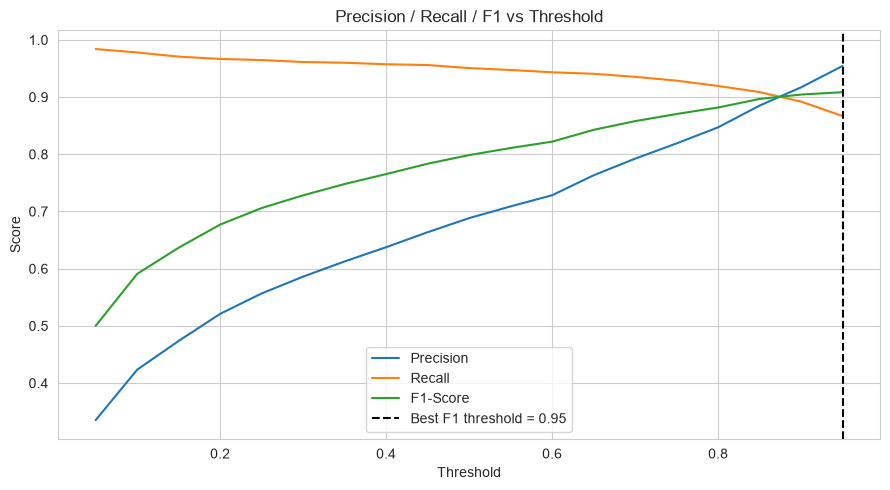

Selected threshold: 0.9500000000000001


In [461]:
thresholds = np.arange(0.05, 0.96, 0.05)
precisions, recalls, f1s = [], [], []

for t in thresholds:
    pred_t = (y_test_proba >= t).astype(int)
    precisions.append(precision_score(y_test, pred_t, zero_division=0))
    recalls.append(recall_score(y_test, pred_t, zero_division=0))
    f1s.append(f1_score(y_test, pred_t, zero_division=0))

best_threshold = thresholds[int(np.argmax(precisions))]

plt.figure(figsize=(9, 5))
plt.plot(thresholds, precisions, label="Precision")
plt.plot(thresholds, recalls, label="Recall")
plt.plot(thresholds, f1s, label="F1-Score")
plt.axvline(best_threshold, color="black", linestyle="--", label=f"Best F1 threshold = {best_threshold:.2f}")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision / Recall / F1 vs Threshold")
plt.legend()
plt.tight_layout()
plt.show()

selected_threshold = best_threshold
print("Selected threshold:", selected_threshold)


In [462]:
y_train_pred_final = (y_train_proba >= selected_threshold).astype(int)
y_test_pred_final = (y_test_proba >= selected_threshold).astype(int)

print("Training (at selected threshold):")
print(f"  Accuracy : {accuracy_score(y_train, y_train_pred_final):.4f}")
print(f"  Precision: {precision_score(y_train, y_train_pred_final):.4f}")
print(f"  Recall   : {recall_score(y_train, y_train_pred_final):.4f}")
print(f"  PR-AUC   : {train_pr_auc:.4f}   (threshold-independent)")

print("\nTesting (at selected threshold):")
print(f"  Accuracy : {accuracy_score(y_test, y_test_pred_final):.4f}")
print(f"  Precision: {precision_score(y_test, y_test_pred_final):.4f}")
print(f"  Recall   : {recall_score(y_test, y_test_pred_final):.4f}")
print(f"  PR-AUC   : {test_pr_auc:.4f}   (threshold-independent)")


Training (at selected threshold):
  Accuracy : 0.9998
  Precision: 0.9733
  Recall   : 0.9945
  PR-AUC   : 0.9978   (threshold-independent)

Testing (at selected threshold):
  Accuracy : 0.9990
  Precision: 0.9545
  Recall   : 0.8668
  PR-AUC   : 0.9577   (threshold-independent)


In [463]:
# ==============================
# 10. THRESHOLD TUNING
# ==============================

import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.10, 0.96, 0.05)

threshold_results = []

for threshold in thresholds:

    y_pred_threshold = (y_test_proba >= threshold).astype(int)

    precision = precision_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df = threshold_df.sort_values(
    by="F1",
    ascending=False
).reset_index(drop=True)

print("=== Threshold Comparison ===")
display(threshold_df.head(5))

=== Threshold Comparison ===


,Threshold,Precision,Recall,F1
0,0.95,0.954512,0.866755,0.908520
1,0.90,0.917123,0.892072,0.904424
2,0.85,0.885140,0.908728,0.896778
3,0.80,0.847145,0.919387,0.881789
4,0.75,0.819036,0.928714,0.870434


In [464]:
selected_threshold=0.85
y_train_pred_final = (y_train_proba >= selected_threshold).astype(int)
y_test_pred_final = (y_test_proba >= selected_threshold).astype(int)

# Final Evaluation

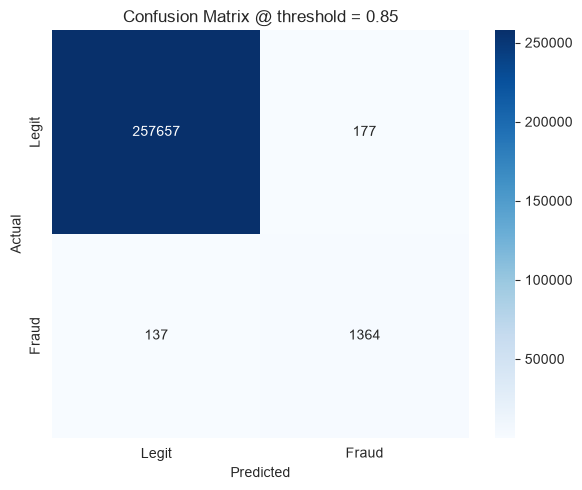

              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00    257834
       Fraud       0.89      0.91      0.90      1501

    accuracy                           1.00    259335
   macro avg       0.94      0.95      0.95    259335
weighted avg       1.00      1.00      1.00    259335



In [465]:
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_test_pred_final), annot=True, fmt="d", cmap="Blues",
            xticklabels=["Legit","Fraud"], yticklabels=["Legit","Fraud"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix @ threshold = {selected_threshold:.2f}")
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_test_pred_final, target_names=["Legit","Fraud"]))


# Save the model

In [466]:
import joblib

joblib.dump({
    "pipeline": final_Pipeline,
    "threshold": selected_threshold,
    "feature_columns": list(X_train.columns),
}, "final_fraud_pipeline.pkl")

print("Saved final_fraud_pipeline.pkl")


Saved final_fraud_pipeline.pkl


In [467]:
# Reload check — this is the pattern to use anywhere else this model gets loaded
loaded = joblib.load("final_fraud_pipeline.pkl")
loaded_pipeline = loaded["pipeline"]
loaded_threshold = loaded["threshold"]

sample = X_test.loc[[1158434]]
proba = loaded_pipeline.predict_proba(sample)[:, 1][0]
pred = int(proba >= loaded_threshold)

print(f"Sample fraud probability: {proba:.4f}")
print(f"Threshold used: {loaded_threshold}")
print(f"Prediction: {'FRAUD' if pred else 'Legitimate'}")

y_proba = loaded_pipeline.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= loaded_threshold).astype(int)

print("PR-AUC:", average_precision_score(y_test, y_proba))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=["Legit", "Fraud"]))


Sample fraud probability: 0.9999
Threshold used: 0.85
Prediction: FRAUD
PR-AUC: 0.9577079947341077
[[257657    177]
 [   137   1364]]
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00    257834
       Fraud       0.89      0.91      0.90      1501

    accuracy                           1.00    259335
   macro avg       0.94      0.95      0.95    259335
weighted avg       1.00      1.00      1.00    259335



In [468]:
n=1158434
te=['Rutherford-Mertz',281.06,'M','NC','Soil scientist',1,2,2,1,30]

display(X_test.loc[[n]])


,merchant,category,amt,gender,state,job,trans_hour,trans_dayofweek,trans_day,trans_month,age
1158434,Pouros-Haag,shopping_pos,685.42,F,PA,Archaeologist,2,1,28,4,33


In [469]:
display( y_test[y_test==1])

74034      1
7554       1
1069312    1
67800      1
568265     1
          ..
1158434    1
897380     1
191546     1
236839     1
896699     1
Name: is_fraud, Length: 1501, dtype: int64

In [470]:
df.iloc[n]

merchant             Pouros-Haag
category            shopping_pos
amt                       685.42
gender                         F
state                         PA
job                Archaeologist
is_fraud                       1
trans_hour                     2
trans_dayofweek                1
trans_day                     28
trans_month                    4
age                           33
Name: 1158434, dtype: object